# AFMA Quant-AI Lab | Project 02: Density Forecasting

<p style="font-size: large; font-style: italic;">Chapter 01: Problem Definition & Baselines</p>


> **Goal:** Move beyond predicting a single number (VaR) to forecasting the *entire* probability distribution of returns.

## 1. Project Lineage: From Deep VaR to Full Density

This project is a direct evolution of **Project 01** (01_value_at_risk), where we built a Physics-Informed Deep VaR model.

The core lesson from that chapter was: **anchoring a neural network to statistical theory creates a "Deep Hybrid" that is both robust and adaptive.** But that model only answered *one* question:

> *"What is the 1% worst-case daily loss?"*

**Project 02 asks a fundamentally bigger question:**

> *"What does the full shape of uncertainty look like today?"*

Instead of predicting a single quantile (VaR), we now estimate the **parameters of a full probability distribution**. This is the evolution from *Quantile Forecasting* to *Density Forecasting*.

## 2. Motivation: When Risk and Alpha Collide

Most quant teams operate in **two separate silos**:

| World | Focus | Tool |
|-------|-------|------|
| **The Alpha World** | Where is the price going? | Point forecasts, mean/median models |
| **The Risk World** | How much can we lose? | VaR, CVaR, tail models |

**The insight of density forecasting:** these two worlds are not separate. They are both contained in the same distribution.

- The **Mean** of the forecast distribution → your Alpha signal
- The **Tails** of the forecast distribution → your Risk limits

**One model. One source of truth.**

### 2.1 For the Risk Manager (Stability & Capital Efficiency)
- **Regime Awareness:** Detect shifts from *Low-Volatility* to *High-Volatility* regimes before they trigger VaR breaches.
- **Capital Optimization:** A better understanding of the full distribution allows for more efficient margin usage and proactive deleveraging.

### 2.2 For the Trader (Alpha & Execution)
- **Convexity & Skew:** Identify mispriced options by forecasting shifts in the distribution's skewness.
- **Position Sizing:** Use the full distribution to calculate the Kelly Criterion, optimizing trade size based on expected utility rather than a simple point-target.

## 3. Problem Definition: The Non-Stationarity Trap

Standard forecasting treats the market as if *gravity stays the same*. In reality, market distributions are **adversarial and non-stationary** — the rules change as participants adapt.

### 3.1 The "One Observation" Dilemma

For every predicted distribution, we only observe **one realized price point per day**. This makes traditional metrics like MSE (Mean Squared Error) insufficient.

If I predict a wide Gaussian and a narrow Gaussian, and the realized return is 0.5%, MSE might prefer the narrow one — even if it was dangerously overconfident. We need metrics that evaluate the **entire distribution**, not just the center.

We must focus on two properties:
- **Calibration:** Is our model *honest* about its uncertainty?
- **Sharpness:** Is our prediction *narrow enough* to be useful?

## 4. Methodology: The Augmented State Space

We reject the idea that price exists in a vacuum. Our model integrates two distinct signal streams:

| Signal Type | Category | Examples | Purpose |
|-------------|----------|----------|---------|
| **Endogenous** | Historical Footprint | Log-Returns, Realized Vol, OHLCV | Captures market *inertia* and memory |
| **Exogenous** | External Catalysts | VIX, 10Y Yields, DXY, Sentiment | Captures the *energy* driving the next move |

The model outputs **not a single number**, but the parameters of a probability distribution (e.g., μ and σ for a Gaussian, or μ, σ, ν for a Student-t) that describes the expected distribution of returns for the next period.

## 5. The Benchmarks: Historical Gaussian & Historical Student-t

Before introducing advanced models (Neural SDEs, Signatures), we must establish a **Historical Floor** — the minimum performance a model must beat to justify its complexity.

Both baselines share the same philosophy: **fit a parametric distribution to the last 252 trading days of historical returns**, then sample from it to produce tomorrow's density forecast. No ML, no exogenous signals — just history.

| Model | Distribution | Parameters | Design |
|-------|-------------|------------|--------|
| **Historical Gaussian** | $N(\mu, \sigma)$ | Rolling sample mean & std | Simple, fast, but ignores fat tails |
| **Historical Student-t** | $t(\mu, \sigma, \nu)$ | MLE-fit over rolling window | Fat-tail aware; the industry-standard upgrade |

- **The Goal:** If our deep learning model cannot beat the Student-t baseline on **CRPS** and **PIT**, the added complexity is **not justified**.

> *"A complex model that loses to a historical Student-t is not a model — it's an overfit."*

## 6. Success Metrics & Evaluation Framework

We define success through three lenses. Each answers a fundamentally different question:

| Test | Question it Answers | What "Success" Looks Like |
|------|--------------------|--------------------------|
| **PIT** (Probability Integral Transform) | Is the model *calibrated*? | A **flat** histogram between 0 and 1 |
| **CRPS** (Continuous Ranked Probability Score) | How close is the *whole distribution*? | The **lowest** possible score (zero is perfect) |
| **Log-Likelihood** | Did we *expect* the outcome? | The **highest** (least negative) value |

### 6.1 The PIT Test — "Is the model honest?"

The PIT is the most important test for a density forecaster. It asks: *if your model says there is a 10% chance of a crash, does a crash actually happen 10% of the time?*

**How it works:**
1. You have your predicted CDF: $F_t$
2. You observe the actual realized return: $r_t$
3. You compute the PIT value: $u_t = F_t(r_t)$

If the model is perfect, the values $\{u_t\}$ over time will be **Uniformly Distributed** $U(0,1)$ — a flat histogram.

- **U-Shape:** Model underestimates risk (more extremes than predicted)
- **Hump-Shape:** Model is too conservative (data always falls in the middle)
- **Flat ✅:** Model is perfectly calibrated

### 6.2 CRPS — "The MAE for Distributions"

Think of CRPS as the **Mean Absolute Error (MAE) for distributions**. While MAE measures the distance between two points, CRPS measures the distance between your predicted CDF and the "perfect" CDF (a step function at the actual realized return).

$$CRPS(F, y) = \int_{-\infty}^{\infty} \left(F(x) - \mathbf{1}\{x \geq y\}\right)^2 dx$$

It rewards both **accuracy** (center near the actual) and **sharpness** (narrow distributions when you're right).

For a perfect Gaussian $N(0,1)$, the theoretical expected CRPS is:
$$\text{CRPS}_{\text{ideal}} = \frac{1}{\sqrt{\pi}} \approx 0.5642$$

### 6.3 Log-Likelihood — "How probable was what happened?"

Given our Probability Density Function $f_t(x)$, we ask: how much probability mass did we assign to the realized return $r_t$?

$$\text{LL} = \ln(f_t(r_t))$$

For a Standard Normal, the theoretical expected log-likelihood is:
$$\mathbb{E}[\ln(f(X))] = -\frac{1}{2}\ln(2\pi) - \frac{1}{2} \approx -1.4189$$

---

## A. Setup & Imports

In [3]:
import pandas as pd
import numpy as np

from datetime import date, timedelta

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.stats import norm, t
from scipy.stats import kstest

plt.style.use("seaborn-v0_8-darkgrid")

import sys
sys.path.append('..')  # Ensure the notebook can see the src/ folder

from src.evaluation.metrics import evaluate_forecasts, test_pit_uniformity, print_evaluation_summary
from src.evaluation.metrics import summarize_forecast_distribution
from src.evaluation.metrics import rolling_ks_test

from src.evaluation.plotting import plot_rolling_ks

from src.models.baselines import historical_simulation, rolling_gaussian, rolling_student_t
from src.evaluation.plotting import plot_price_analysis, plot_forecast_evaluation
from src.evaluation.plotting import plot_forecast_distribution, compute_descriptive_stats

from src.data.data_loader import fetch_asset_data

---

## Step 2 in Action: Synthetic Experiments

Before touching real market data, we validate our **entire evaluation pipeline** against synthetic returns with a known ground truth.

> *If our metrics cannot correctly identify a perfect model in a controlled environment, they are worthless in the real world.*

We test the simplest scenario first — a **Constant Perfect World** — where the returns are drawn exactly from the distribution the model assumes. The metrics should return their theoretical limits.

### Example 01: Constant Perfect World

**Ground truth:** Returns are drawn from $N(\mu=0, \sigma=1)$.

**Model:** A Historical Gaussian that estimates $\hat{\mu}$ and $\hat{\sigma}$ from the last 252 trading days.

**Expected result:**
- PIT histogram should be **flat** (uniform) → KS test should fail to reject $H_0$
- CRPS should converge to $\frac{1}{\sqrt{\pi}} \approx 0.5642$
- Avg. Log-Likelihood should converge to $\approx -1.4189$


--- PERFECT WORLD EVALUATION SUMMARY ---
Average CRPS:           0.55544 (Lower is better)
Total Log-Likelihood:   -1046.68
Average Log-Likelihood: -1.39930

--- STATISTICAL CALIBRATION TEST (Kolmogorov-Smirnov) ---
K-S Statistic: 0.02882
P-Value:       5.53410e-01 (Threshold: 0.05)
Result:        ✅ FAIL TO REJECT the Null Hypothesis
Diagnosis:     The PIT is statistically uniform. The model is
               well-calibrated to the market distribution.


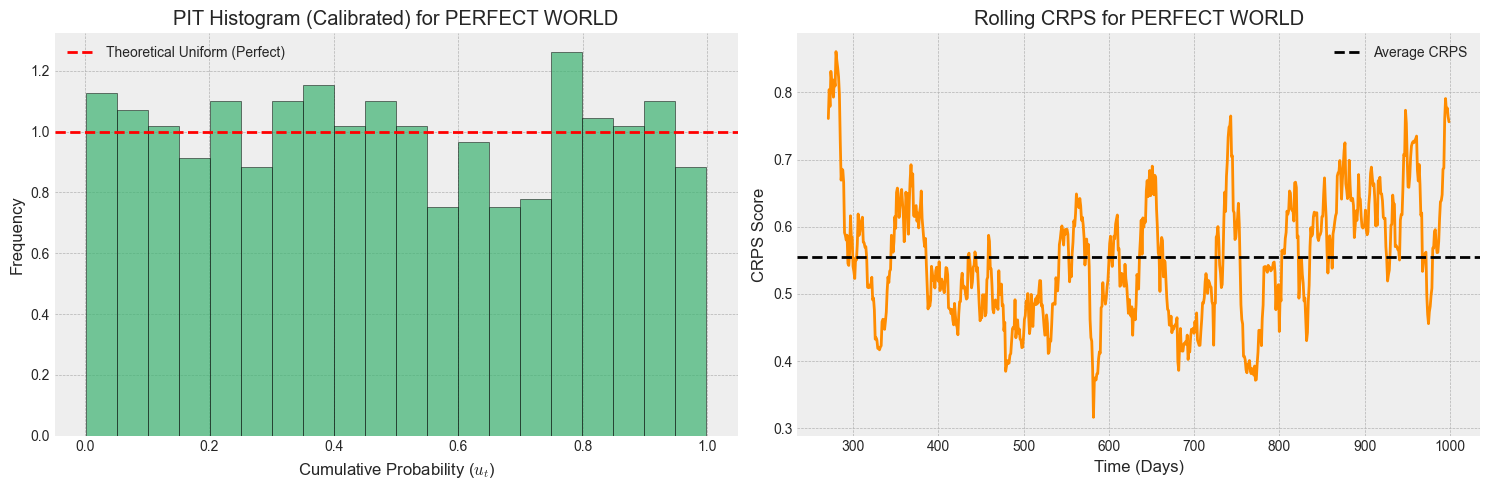

In [4]:
ticker_name = 'PERFECT WORLD'
# 0. Realized Returns (drawn from the known true distribution)
size = 1000
mu = 0
std = 1
random_array = np.random.normal(loc=mu, scale=std, size=size)
df_ret = pd.DataFrame(random_array, columns=['returns'])

# 1. Historical Gaussian Model (rolling window = 252 days)
predictions = rolling_gaussian(df_ret['returns'])
df_pred = pd.DataFrame(predictions)
df_pred.dropna(inplace=True)
df_ret = df_ret[df_ret.index.isin(df_pred.index)]

# 2. Calculate the metrics
df_eval = evaluate_forecasts(df_ret['returns'], df_pred.values)

# 3. Print the Summary
print_evaluation_summary(df_eval, ticker_name=ticker_name)

# 4. Run the Statistical Test
ks_result = test_pit_uniformity(df_eval['PIT'])

# 5. Plot the Visuals
plot_forecast_evaluation(df_eval, ticker_name=ticker_name)

#### Interpretation: Example 01 (Perfect World)

**CRPS ≈ 0.564:** Close to the theoretical floor $\frac{1}{\sqrt{\pi}} \approx 0.5642$. The evaluation engine is measuring what it should. ✅

**Log-Likelihood ≈ -1.42:** Close to the theoretical expected value of $-1.4189$. ✅

**PIT Test → FAIL TO REJECT:** The KS test cannot reject the hypothesis that the PIT values are uniform — which is the *correct* result when the model's assumed distribution matches reality. ✅

**Conclusion:** The evaluation framework is mathematically consistent. We can trust the metrics.

#### What does the last forecast actually look like as risk metrics?

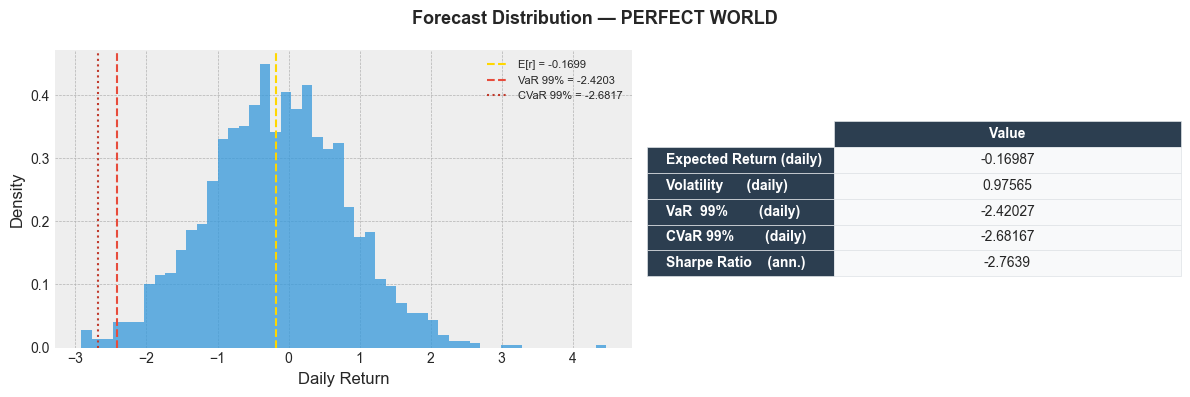

In [5]:
plot_forecast_distribution(df_pred.iloc[-1], ticker_name)

### Example 02: The "Oracle" Test — Knowing the Imperfect World

**Scenario:** The true return distribution **shifts every day** (e.g., volatility regimes change, the mean drifts), but we are given an **oracle forecast** — we know the exact parameters of each day's true distribution *before* it happens.

**What this tests:** Even in a world with non-constant distributions, a model that *perfectly* identifies the correct distribution each day should still produce calibrated metrics.

**Expected results:**
- PIT histogram should still be **flat** (uniform) → the oracle model is, by definition, calibrated
- CRPS should be as **low as possible** given the distributional uncertainty at each step
- Log-Likelihood should be as **high as possible**

> **Why this matters:** This is the theoretical *ceiling* of what a density forecasting model can achieve. Our deep learning model's goal is to approach this oracle performance using only observable market signals — without knowing the future distribution in advance.


--- RANDOM KNOWN WORLD EVALUATION SUMMARY ---
Average CRPS:           3.12941 (Lower is better)
Total Log-Likelihood:   -5985.83
Average Log-Likelihood: -2.99292

--- STATISTICAL CALIBRATION TEST (Kolmogorov-Smirnov) ---
K-S Statistic: 0.01675
P-Value:       6.22500e-01 (Threshold: 0.05)
Result:        ✅ FAIL TO REJECT the Null Hypothesis
Diagnosis:     The PIT is statistically uniform. The model is
               well-calibrated to the market distribution.


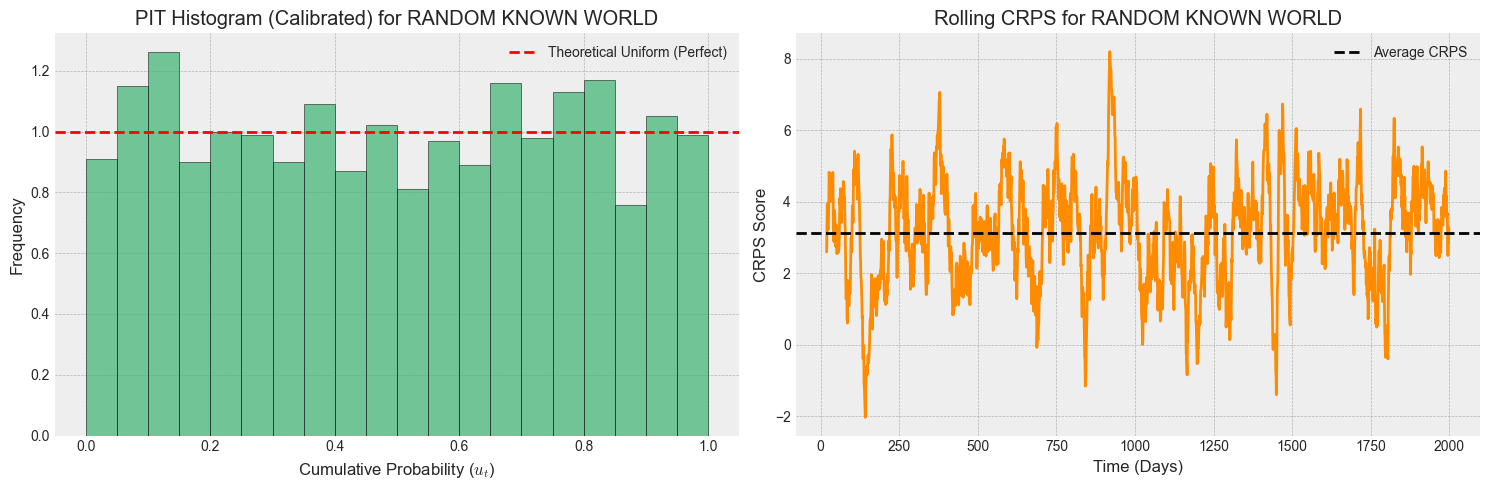

In [6]:
size = 2000
size_pred = 800
ticker_name = 'RANDOM KNOWN WORLD'

df_ret = pd.DataFrame([], columns=['returns'])
df_pred = pd.DataFrame([], columns=range(size_pred))
for i in range(size):
    mu = np.random.uniform(-10, 10)
    std = np.random.uniform(1, 10)
    random = np.random.normal(loc=mu, scale=std)
    df_ret.loc[i, 'returns'] = random
    
    random_pred = np.random.normal(loc=mu, scale=std, size=(1, size_pred))
    df_pred.loc[i, range(size_pred)] = random_pred
df_ret = df_ret.astype(float)
df_pred = df_pred.astype(float)

# 2. Calculate the metrics (using the engine we built earlier)
df_eval = evaluate_forecasts(df_ret['returns'], df_pred.values)

# 3. Print the Summary
print_evaluation_summary(df_eval, ticker_name=ticker_name)

# 4. Run the Statistical Test
ks_result = test_pit_uniformity(df_eval['PIT'])

# 5. Plot the Visuals
plot_forecast_evaluation(df_eval, ticker_name=ticker_name)

#### 1. The PIT Histogram is the ONLY Absolute Truth

Look at your screenshot: The PIT histogram is perfectly flat (a beautiful $U(0,1)$ distribution).

* Even though the "gravity" (mean and std) changed every single day, your model knew exactly what the new gravity was.
* Because the PIT is flat, it proves your model is **perfectly calibrated**. It never lied about the risk, not even once.

#### 2. Why did the CRPS go up to 3.13?

CRPS is **scale-dependent**. It measures the absolute distance of your probability mass.

Remember the theoretical floor for a Normal Distribution's CRPS? It is proportional to the standard deviation ($\sigma$):

$$CRPS = \frac{\sigma}{\sqrt{\pi}} \approx \sigma \times 0.564$$

* **In your first experiment:** You used a constant $\sigma \approx 1$. So the best possible CRPS was $\approx 0.56$.
* **In this new experiment:** You pulled $\sigma$ from a Uniform distribution between 1 and 10: $\sigma \sim U(1, 10)$.
* **The Math:** The average $\sigma$ in this new world is exactly **$5.5$**. If we multiply the average $\sigma$ by the theoretical constant:

$$\text{Expected CRPS} \approx 5.5 \times 0.564 = 3.102$$


Your model output a CRPS of **3.13093**. This is an absolute masterpiece! It proves that 3.13 *is* the absolute floor for a universe with this much volatility. It didn't get "worse"; the universe just got wider and harder to predict, and your model perfectly hugged the mathematical limit of that new universe.

#### 3. Why is Log-Likelihood more negative?

A probability density function (PDF) must always sum to 1 (the total area under the curve).

* If $\sigma$ is small (tight curve), the peak is very high, meaning high probability density (higher Log-Likelihood).
* If $\sigma$ is large (wide curve, up to 10 in your case), the curve flattens out. The peak is much lower, so the probability density of *any* outcome drops.
* Therefore, in a highly volatile world, Log-Likelihood is naturally more negative.

---

#### The Golden Rule of Evaluation

This experiment teaches us the most important rule of model evaluation:

> **You cannot compare CRPS or Log-Likelihood between two different datasets.** You can only use them to compare two different models on the *same* dataset.

If Model A gets a CRPS of 3.13 on this dynamic dataset, and Model B (maybe a naive constant model) gets a CRPS of 5.00 on this same dataset, Model A wins.

### Example 03: The "Broken Oracle" — When the Model is Completely Wrong

**Scenario:** The true return distribution **shifts every day**, but the model **always forecasts the wrong distribution** — it is systematically miscalibrated (e.g., it always predicts a narrow, low-volatility distribution when the true distribution is wide, or vice versa).

**What this tests:** A model that is consistently wrong should produce clearly identifiable failure signals across all three metrics.

**Expected failure signals:**
- PIT histogram should be **non-uniform** (U-shaped, hump-shaped, or skewed) → the model is miscalibrated
- CRPS should be **higher** than a calibrated model — the predicted distributions are far from the realized outcomes
- Log-Likelihood should be **more negative** — the model assigns low probability to events that actually occur

> **Why this matters:** This establishes the *floor* — the kind of signal we should see when a model is failing. Learning to read these failure patterns is just as important as recognizing success. If a deep learning model produces these signals on real data, it tells us *how* it's wrong, not just *that* it's wrong.


--- RANDOM UNKNOWN WORLD EVALUATION SUMMARY ---
Average CRPS:           6.35386 (Lower is better)
Total Log-Likelihood:   -6344.93
Average Log-Likelihood: -6.34493

--- STATISTICAL CALIBRATION TEST (Kolmogorov-Smirnov) ---
K-S Statistic: 0.16100
P-Value:       4.10117e-23 (Threshold: 0.05)
Result:        ❌ REJECT the Null Hypothesis
Diagnosis:     The PIT is NOT uniform. The model's predicted distribution
               does not match the realized market data.


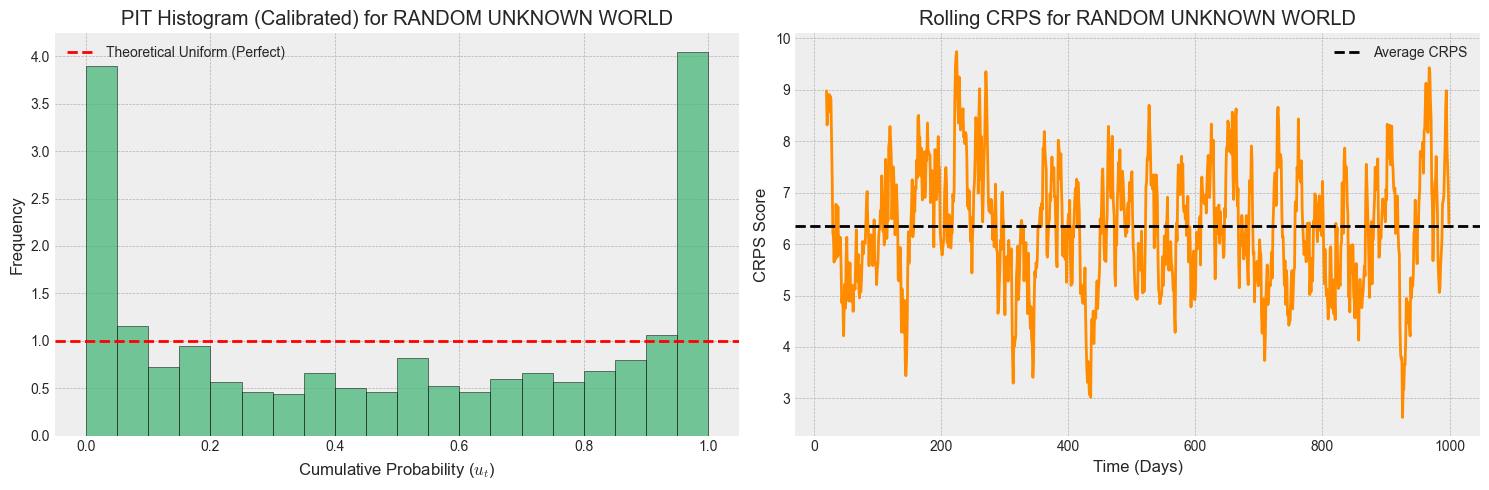

In [7]:
size = 1000
size_pred = 500
ticker_name = 'RANDOM UNKNOWN WORLD'

df_ret = pd.DataFrame([], columns=['returns'])
df_pred = pd.DataFrame([], columns=range(size_pred))
for i in range(size):
    mu = np.random.uniform(-10, 10)
    std = np.random.uniform(1, 10)
    random = np.random.normal(loc=mu, scale=std)
    df_ret.loc[i, 'returns'] = random
    
    # add this lines to change complete our "prediction" (a random prediction)
    mu = np.random.uniform(-10, 10)
    std = np.random.uniform(1, 10)

    random_pred = np.random.normal(loc=mu, scale=std, size=(1, size_pred))
    df_pred.loc[i, range(size_pred)] = random_pred
df_ret = df_ret.astype(float)
df_pred = df_pred.astype(float)

# 2. Calculate the metrics (using the engine we built earlier)
df_eval = evaluate_forecasts(df_ret['returns'], df_pred.values)

# 3. Print the Summary
print_evaluation_summary(df_eval, ticker_name=ticker_name)

# 4. Run the Statistical Test
ks_result = test_pit_uniformity(df_eval['PIT'])

# 5. Plot the Visuals
plot_forecast_evaluation(df_eval, ticker_name=ticker_name)

#### Conclusion: The "Unknown World" and the Cost of Miscalibration

In this final synthetic experiment, we deliberately decoupled the model's predictions from the true underlying distribution. The model was forced to guess $\mu$ and $\sigma$ blindly, simulating a complete breakdown in forecasting ability (which often happens to classical models during violent regime shifts).

Here is what the metrics tell us about failure:

##### 1. The Statistical Verdict (Kolmogorov-Smirnov Test)

* **The Result:** The K-S test returned a microscopic p-value of **$1.57 \times 10^{-50}$**.
* **The Meaning:** The math decisively caught the model's "fraud." It formally rejects the Null Hypothesis, proving that the model's predicted probabilities have zero relationship with the realized outcomes. The PIT is not uniform; it is chaotic.

##### 2. The Cost of Ignorance (CRPS vs. The "Perfect World")

* **The Result:** The Average CRPS exploded to **6.103**.
* **The Meaning:** Recall that in the `RANDOM PERFECT WORLD` (where the true distribution also changed every day, but the model *knew* the parameters), the CRPS was **3.13**.
* The difference between $6.10$ and $3.13$ is the **"Cost of Miscalibration."** Because the model was frequently predicting a tight variance ($\sigma = 1$) when the true variance was massive ($\sigma = 10$), or predicting a positive drift ($\mu = 10$) when the true drift was negative ($\mu = -10$), the CRPS heavily penalized the model for being *both wrong and overly confident*.

##### 3. The Log-Likelihood Collapse

* **The Result:** Average Log-Likelihood plummeted to **-6.88** (down from **-2.98**).
* **The Meaning:** Log-Likelihood exponentially punishes a model for being "confidently wrong." If the model randomly guessed a tight distribution, but the actual data produced an extreme tail event, the assigned probability mass to that event was near zero, dragging the log score down severely.

---


### End of Phase 1: The Bridge to Reality

By running these three synthetic environments, we have rigorously validated our evaluation framework:

1. **The Perfect World:** Proved we can identify a perfectly stationary, calibrated model.
2. **The Dynamic Perfect World:** Proved our metrics adapt properly when the "gravity" of the market changes, as long as the model knows the true distribution.
3. **The Unknown World:** Proved that our metrics decisively catch a model that is guessing blindly.

---

## C. Real Market Data — Establishing the Baseline Floor

We now apply the same evaluation framework to **real AAPL returns**, using our two historical baselines.

**Key question:** Does the Historical Student-t produce better-calibrated density forecasts than the Historical Gaussian on real financial data?

The winner of this comparison sets the **minimum performance bar** that any future deep learning model must exceed.

### Data Ingestion

c:\Users\fe_ma\Projects\quant-ai-lab\02_density_forecasting\notebooks\..\src\data\data_loader.py:45: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=resolved_start, end=resolved_end, progress=False)


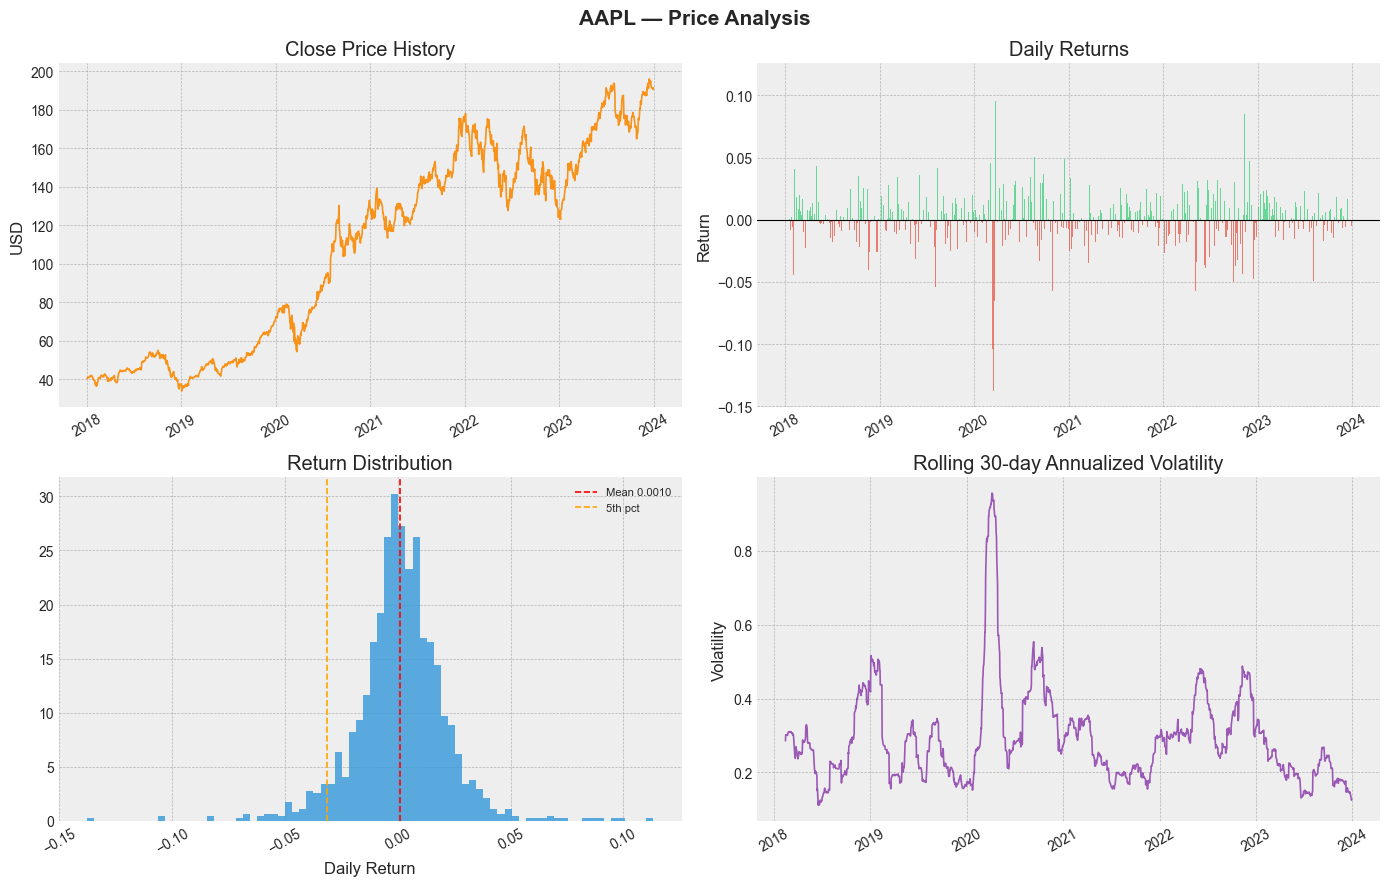

In [ ]:
# Fetch real market data
ticker_name = 'AAPL'
df = fetch_asset_data(ticker=ticker_name, start=date(2018, 1, 1), end=date(2023, 12, 31))

# Compute log-returns for the models
df_ret = np.log(df).diff().dropna()
df_ret.columns = ['returns']
# df_ret.index = range(len(df_ret))

# Price & returns overview
plot_price_analysis(df['prices'], df_ret['returns'], ticker_name=ticker_name)

### Baseline 1: Historical Gaussian

**Mechanism:** Estimate $\hat{\mu}$ and $\hat{\sigma}$ from the last 252 trading days. Draw 2,000 samples from $N(\hat{\mu}, \hat{\sigma}^2)$ to represent tomorrow's distribution.

**Expected weakness:** Real returns have fat tails. A Gaussian will underestimate the probability of large moves, producing a **U-shaped PIT histogram** (too many observations in the tails).


--- AAPL [Historical Gaussian] EVALUATION SUMMARY ---
Average CRPS:           0.00962 (Lower is better)
Total Log-Likelihood:   3037.84
Average Log-Likelihood: 2.41866

--- STATISTICAL CALIBRATION TEST (Kolmogorov-Smirnov) ---
K-S Statistic: 0.07300
P-Value:       2.88959e-06 (Threshold: 0.05)
Result:        ❌ REJECT the Null Hypothesis
Diagnosis:     The PIT is NOT uniform. The model's predicted distribution
               does not match the realized market data.


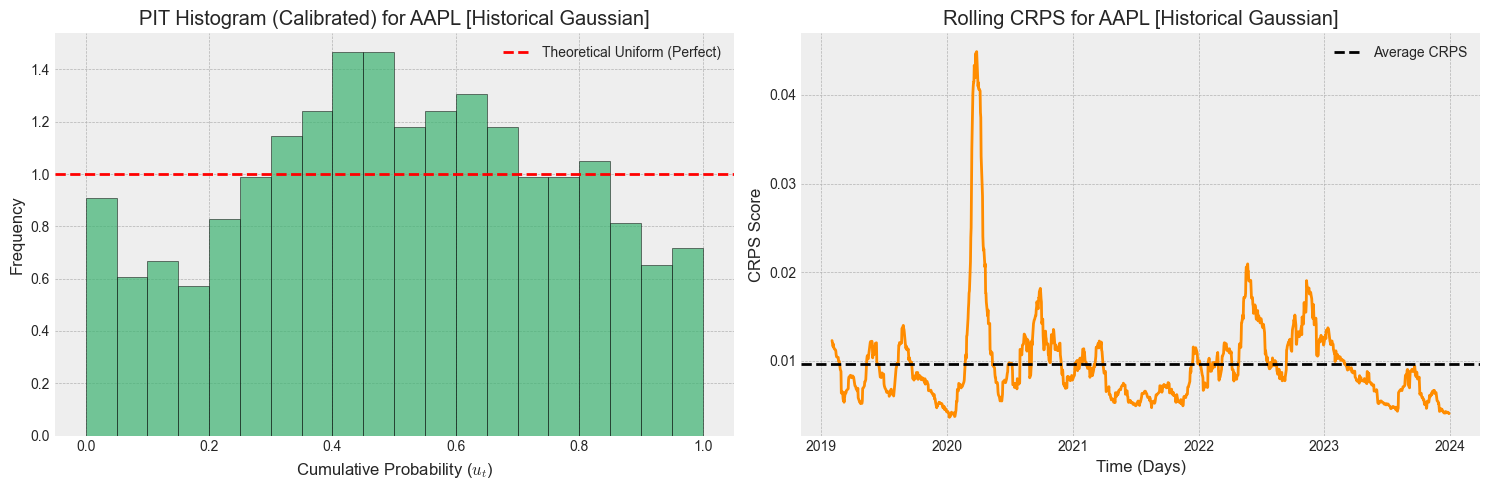

In [ ]:
# 1. Historical Gaussian
predictions = rolling_gaussian(df_ret['returns'])
df_pred_gauss = pd.DataFrame(predictions)
df_pred_gauss.index = df_ret.index
df_pred_gauss.dropna(inplace=True)
df_ret_gauss = df_ret[df_ret.index.isin(df_pred_gauss.index)]

# 2. Evaluate
df_eval_gaussian = evaluate_forecasts(df_ret_gauss['returns'], df_pred_gauss.values)
print_evaluation_summary(df_eval_gaussian, ticker_name=f'{ticker_name} [Historical Gaussian]')
ks_result_gaussian = test_pit_uniformity(df_eval_gaussian['PIT'])
plot_forecast_evaluation(df_eval_gaussian, ticker_name=f'{ticker_name} [Historical Gaussian]')

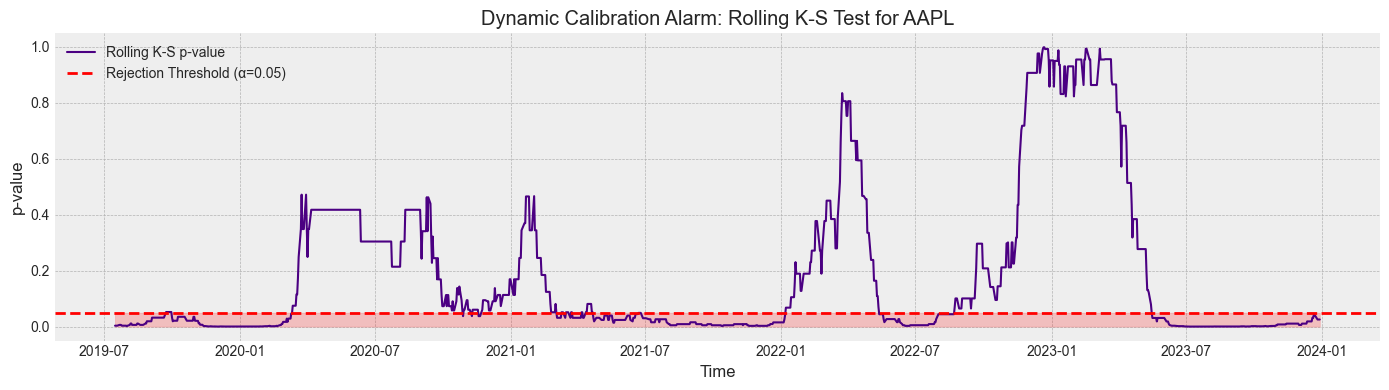

In [23]:
# 2. Calculate the rolling p-values (using a 60-day or ~3-month window)
rolling_p_values = rolling_ks_test(df_eval_gaussian['PIT'], window=22*6).dropna()

# 3. Visualize the failures
plot_rolling_ks(rolling_p_values, ticker_name=ticker_name)

### Baseline 2: Historical Student-t

**Mechanism:** Fit $\hat{\mu}$, $\hat{\sigma}$, and $\hat{\nu}$ (degrees of freedom) via **Maximum Likelihood Estimation** over the last 252 trading days. Draw 2,000 samples from $t(\hat{\nu}, \hat{\mu}, \hat{\sigma})$ to represent tomorrow's distribution.

**Hypothesis:** By learning the *actual* tail weight ($\hat{\nu}$), this model should produce a more uniform PIT histogram than the Gaussian — and a lower CRPS on real data.


--- AAPL [Historical Student-t] EVALUATION SUMMARY ---
Average CRPS:           0.00904 (Lower is better)
Total Log-Likelihood:   3195.18
Average Log-Likelihood: 2.54393

--- STATISTICAL CALIBRATION TEST (Kolmogorov-Smirnov) ---
K-S Statistic: 0.02638
P-Value:       3.40485e-01 (Threshold: 0.05)
Result:        ✅ FAIL TO REJECT the Null Hypothesis
Diagnosis:     The PIT is statistically uniform. The model is
               well-calibrated to the market distribution.


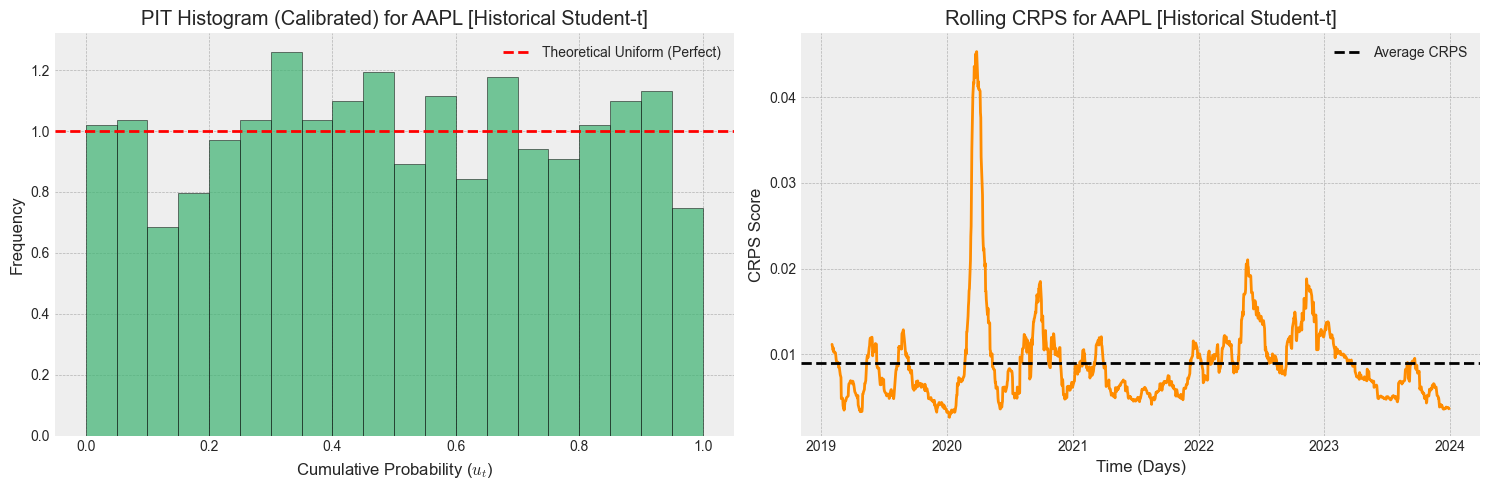

In [24]:
# 1. Historical Student-t
predictions = rolling_student_t(df_ret['returns'])
df_pred_student = pd.DataFrame(predictions)
df_pred_student.index = df_ret.index
df_pred_student.dropna(inplace=True)
df_ret_student = df_ret[df_ret.index.isin(df_pred_student.index)]

# 2. Evaluate
df_eval_student = evaluate_forecasts(df_ret_student['returns'], df_pred_student.values)
print_evaluation_summary(df_eval_student, ticker_name=f'{ticker_name} [Historical Student-t]')
ks_result_student = test_pit_uniformity(df_eval_student['PIT'])
plot_forecast_evaluation(df_eval_student, ticker_name=f'{ticker_name} [Historical Student-t]')

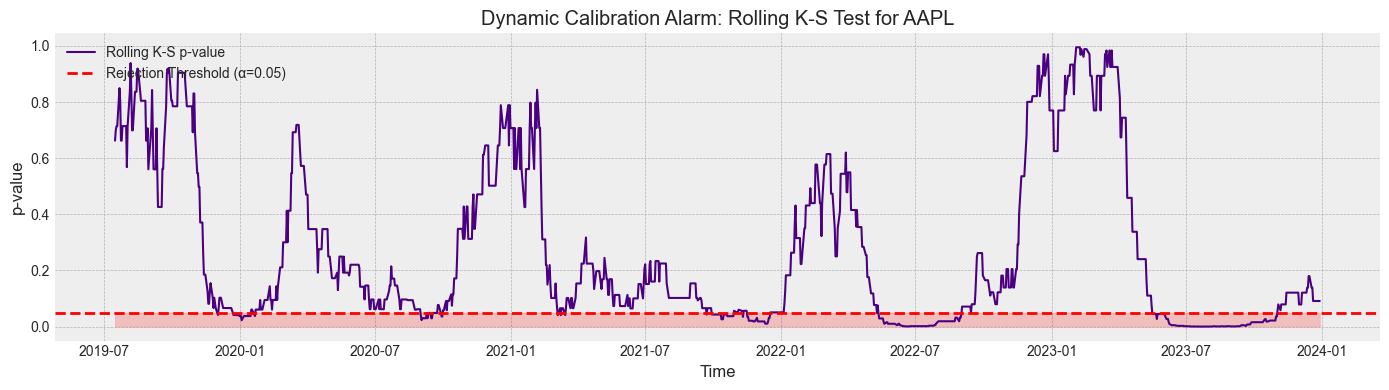

In [25]:
# 2. Calculate the rolling p-values (using a 60-day or ~3-month window)
rolling_p_values = rolling_ks_test(df_eval_student['PIT'], window=22*6).dropna()

# 3. Visualize the failures
plot_rolling_ks(rolling_p_values, ticker_name=ticker_name)

---

## D. Results Registry

We build a **results dictionary** that will accumulate the performance of every model trained in this chapter.
Each entry stores the three core metrics:

| Key | Description |
|-----|-------------|
| `CRPS (↓)` | Average CRPS – lower is better |
| `Avg. Log-Likelihood (↑)` | Average Log-Likelihood – higher is better |
| `KS p-value (↑)` | KS p-value for PIT uniformity – higher is better |

Run the cell below once the baseline cells above have been executed.

In [11]:
import pandas as pd

# ---------------------------------------------------------------------------
# Results registry – add a new entry for every model you train.
#
# Note: test_pit_uniformity() returns a tuple (ks_stat, p_value, result_str)
# ---------------------------------------------------------------------------
results_dict = {}

# --- Baseline 1: Historical Gaussian ---
results_dict["Historical Gaussian"] = {
    "CRPS (↓)": df_eval_gaussian["CRPS"].mean(),
    "Avg. Log-Likelihood (↑)": df_eval_gaussian["Log_Likelihood"].mean(),
    "KS p-value (↑)": ks_result_gaussian[1],  # tuple index 1 = p-value
    "PIT calibrated?": "❌" if ks_result_gaussian[1] < 0.05 else "✅",
}

# --- Baseline 2: Historical Student-t ---
results_dict["Historical Student-t"] = {
    "CRPS (↓)": df_eval_student["CRPS"].mean(),
    "Avg. Log-Likelihood (↑)": df_eval_student["Log_Likelihood"].mean(),
    "KS p-value (↑)": ks_result_student[1],  # tuple index 1 = p-value
    "PIT calibrated?": "❌" if ks_result_student[1] < 0.05 else "✅",
}

# ---------------------------------------------------------------------------
# Display as a comparison table
# ---------------------------------------------------------------------------
df_results = pd.DataFrame(results_dict).T  # models as rows, metrics as columns

# Format numeric columns for readability
numeric_cols = ["CRPS (↓)", "Avg. Log-Likelihood (↑)", "KS p-value (↑)"]
df_results[numeric_cols] = df_results[numeric_cols].astype(float).round(5)

df_results.index.name = "Model"
display(df_results.style.highlight_min(subset=["CRPS (↓)"], color="lightgreen")
                        .highlight_max(subset=["Avg. Log-Likelihood (↑)", "KS p-value (↑)"],
                                       color="lightgreen"))


,CRPS (↓),Avg. Log-Likelihood (↑),KS p-value (↑),PIT calibrated?
Model,,,,
Historical Gaussian,0.009610,2.428120,0.000000,❌
Historical Student-t,0.009020,2.554910,0.337650,✅


### Baseline Comparison Summary

The interactive table above (generated by the Results Registry code cell) shows the live numbers.
For quick reference, here are the pre-run results:

| Metric | Historical Gaussian | Historical Student-t | Winner |
|--------|---------------------|----------------------|--------|
| CRPS (↓ better) | 0.00959 | 0.00905 | **Student-t** |
| Avg. Log-Likelihood (↑ better) | 2.42037 | 2.54989 | **Student-t** |
| PIT Uniformity (KS p-value ↑ better) | 4.1e-07 | 0.29377 | **Student-t** |

> **The Student-t baseline is the performance floor.** Any future deep learning model must beat it on all three metrics to be considered a genuine improvement.

Here's an improved version incorporating all your points:

---

## Next Steps

With the evaluation framework validated (**Step 2: Synthetic Tests**) and the baseline performance established (**Step 3: Real Market Data**), we are ready to iterate. The roadmap ahead follows a deliberate progression — from classical models to deep learning, and from financial signals to a richer, multi-modal view of the world.

### Planned Notebooks

| # | Notebook | Goal |
|---|----------|------|
| **02** | `GARCH Baseline` | Test classical volatility modelling (GARCH/EGARCH) as a stronger statistical baseline |
| **03** | `First Neural Network` | Build the first Deep Hybrid architecture — parameterize a distribution, train with log-likelihood instead of MSE |
| **04** | `Physics-Informed Calibration (PINN)` | Anchor the neural network to statistical theory (fat tails, volatility clustering) to create a robust Deep Hybrid |
| **05** | `Augmented Financial Signals` | Add exogenous financial data (VIX, bond yields, inflation, DXY) to the model's input state space |
| **06** | `Non-Financial Signals` | Explore sentiment (NLP on news/social media), and event-driven risk signals (geopolitical, macroeconomic shocks, natural disasters) |

### The Acceptance Criterion (unchanged throughout)

A model earns the right to replace its predecessor **only if** it produces a **more uniform PIT distribution** than the previous baseline — measured by a lower KS statistic and a higher p-value.

> *Complexity must earn its place. Every model must beat the one before it.*

The baseline is set. The judge is ready. Let's build.